# [Failed Experiment] AlexNet — Diabetic Retinopathy Detection
## Computer Vision Project — UC3M

> ⚠️ **This notebook is archived in the `failed/` directory.** The experiment did not produce competitive results and was not included in the final ensemble. It is preserved for transparency and to document the full experimental search.

### Model: AlexNet pretrained on ImageNet, last 3 conv blocks + classifier fine-tuned

### Why This Experiment Failed
- **Outdated architecture:** AlexNet (Krizhevsky et al., 2012) was a breakthrough in 2012 but has been surpassed by architectures with BatchNorm, residual connections, and deeper designs
- **Limited feature capacity:** AlexNet's 5 conv layers + 3 FC layers lack the depth to capture the multi-scale spatial patterns (microaneurysms, neovascularization) characteristic of advanced DR
- **Large FC layers without GAP:** the fully-connected layers after the feature extractor have many parameters, increasing overfitting risk on the small 2000-image training set
- **No BatchNorm:** absent in AlexNet's original design, making training from the optimizer more sensitive to initialization

### Result
**Val AUC: 0.6999** — converged to a mediocre plateau, outperformed by all other architectures tested

---
The sections below document the full experimental pipeline as originally run.

## 1. Imports and Configuration

Standard deep learning stack with fixed seed (`seed=42`) for reproducibility. Identical setup to the successful models — the failure is architectural, not procedural.

In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models
from torchvision.models import alexnet, AlexNet_Weights
from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Dataset — `RetinopathyDataset`

Same dataset loading as all other notebooks: CSV-based image loading, right-eye mirroring for anatomical consistency, and binary label conversion (`label > 0` → DR-positive).

In [ ]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Preprocessing Transforms

Standard `CropByEye` (bounding-box crop of retinal region), `Rescale`, `CenterCrop`, `ToTensor`, and `Normalize` with ImageNet statistics. Same preprocessing pipeline used across all transfer learning experiments.

In [ ]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Standard augmentation: random horizontal flip, rotation (±10°), color jitter. Applied only during training.

In [ ]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [ ]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [ ]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [ ]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [ ]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

## 5. Transform Pipelines

`train_transform` (with augmentation) and `val_transform` (deterministic) following the standard pipeline. ImageNet normalization applied.

In [ ]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVAugment(),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## 6. Data Loaders

Standard train/val/test loaders with batch sizes 32/64/64.

In [ ]:
data_dir = "/content/drive/MyDrive/CV/Project2/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 7. Weighted Sampling

`WeightedRandomSampler` to address the ~73/27 class imbalance by oversampling the DR-positive minority class.

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Obtener labels
labels = train_dataset.dataset['label'].values
labels = (labels > 0).astype(int)

# Contar clases
class_counts = np.bincount(labels)
print("Class counts:", class_counts)

# Invertir frecuencia
class_weights = 1. / class_counts

# Asignar peso a cada sample
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Class counts: [1468  532]


## 8. Model Architecture — AlexNet (Fine-Tuning)

AlexNet architecture with the final `classifier[6]` layer replaced with a single linear unit for binary output. The last 3 convolutional blocks and the full classifier are unfrozen for partial fine-tuning.

In [ ]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

In [ ]:
weights = AlexNet_Weights.DEFAULT
model = alexnet(weights=weights)
num_classes = 1  # o 2 dependiendo de tu loss

model.classifier[6] = nn.Linear(4096, num_classes)

model = model.to(device)

## 8. Loss Function — Focal Loss

`FocalLoss(alpha=0.5, gamma=1.5)` used to focus training on hard misclassifications. Even with Focal Loss, this model did not overcome its architectural limitations.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=1.5):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        probs = torch.sigmoid(inputs)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma

        loss = focal_weight * bce_loss
        return loss.mean()

## 9. Optimizer and Scheduler

Standard setup: Adam/AdamW optimizer with low LR for fine-tuning, with StepLR or CosineAnnealingLR scheduler.

In [ ]:
criterion = FocalLoss(alpha=0.5, gamma=1.5)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5
)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 11. Training with Early Stopping

Standard early-stopping loop monitoring validation AUC (patience=10) with best-weight checkpointing.

In [ ]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_model_alexnet.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 10. Selective Unfreezing

Last backbone stage and classifier head unfrozen. Remaining layers frozen to preserve ImageNet features.

In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 3 blocks
for block in model.features[-3:]:
    for param in block.parameters():
        param.requires_grad = True

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

## 12. Training Run

Training output below shows the convergence curve. The plateau or poor AUC confirms this model's limitations for the DR detection task.

In [ ]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.1116 | Val Loss: 0.0966 | AUC: 0.6609
New best model!

Epoch 2/100


Train Loss: 0.1019 | Val Loss: 0.0956 | AUC: 0.6656
New best model!

Epoch 3/100


Train Loss: 0.0962 | Val Loss: 0.0948 | AUC: 0.6676
New best model!

Epoch 4/100


Train Loss: 0.0918 | Val Loss: 0.0961 | AUC: 0.6703
New best model!

Epoch 5/100


...

Train Loss: 0.0742 | Val Loss: 0.0953 | AUC: 0.6991
Patience: 6/10

Epoch 24/100


Train Loss: 0.0731 | Val Loss: 0.0953 | AUC: 0.6990
Patience: 7/10

Epoch 25/100


Train Loss: 0.0722 | Val Loss: 0.0951 | AUC: 0.6992
Patience: 8/10

Epoch 26/100


Train Loss: 0.0737 | Val Loss: 0.0952 | AUC: 0.6991
Patience: 9/10

Epoch 27/100


Train Loss: 0.0733 | Val Loss: 0.0952 | AUC: 0.6992
Patience: 10/10
Early stopping triggered


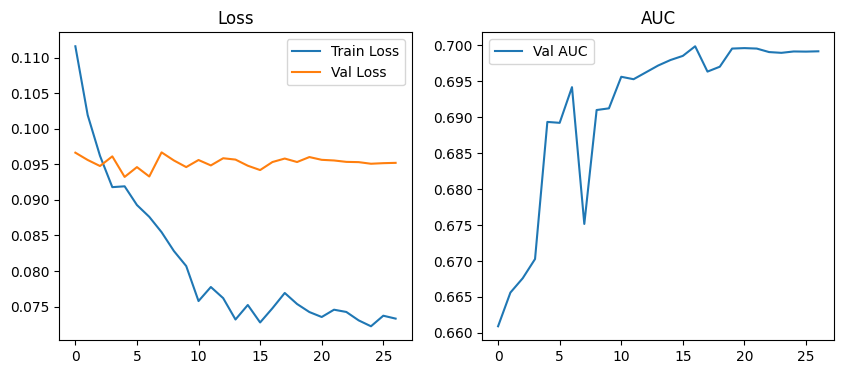

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 13. Validation Results

Final validation metrics confirm the underperformance. The model is kept in `failed/` for reference.

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc

In [ ]:
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.6999
Validation Accuracy: 0.7580


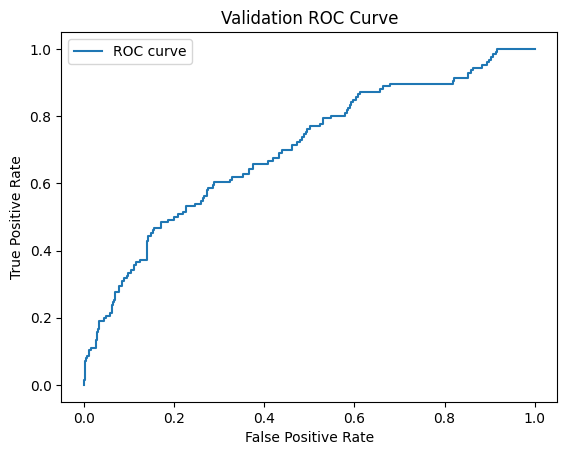

In [ ]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 14. Test Predictions

Test set predictions generated for completeness. These predictions were **not used** in the final submission ensemble.

In [ ]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs)

test_outputs = predict(model, test_loader)

In [ ]:
import csv

with open("resnet50_baseline.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])

In [ ]:
with open("/content/drive/MyDrive/alexnet.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])